# Train Phase:

    Normal Images
        ↓
    YOLO Feature Extractor
        ↓
    Online Adapter (initialized as identity)
        ↓
    Memory Bank of Normal Features

# Test-Time Phase:

    Incoming Image
        ↓
    YOLO Feature Extractor
        ↓
    Online Adapter
        ↓
    Compare with Memory Bank
        ↓
    Anomaly Score
        ↓
    Normal-like sample?
       ├─ No  → Output anomaly result
       └─ Yes → Online Adapter Update
                    ↓
                Update Memory Bank
                    ↓
                Output updated result


# Improveded version:

# Test-Time Phase: Open-Ended Anomaly Detection

    Incoming Test Image
            ↓
    YOLO Feature Extractor
            ↓
    Online Adapter
            ↓
    Test Feature Embedding
            ↓
    Select Top-K Normal Reference Features from Memory Bank
            ↓
    Compare Test Feature with Normal Reference Features
            ↓
    Calculate Anomaly Score
            ↓
    Generate Result
            ├─ Image-Level Result: Normal / Anomaly
            └─ Optional: Pixel-Level Anomaly Map
            ↓
    Normal-like sample?
            ├─ No
            │    ↓
            │  Output Anomaly Result
            │
            └─ Yes
                 ↓
               Online Adapter Update
                 ↓
               Add New Normal-like Feature to Memory Bank
                 ↓
               Updated Normal Representation
                 ↓
               Output Normal Result
                
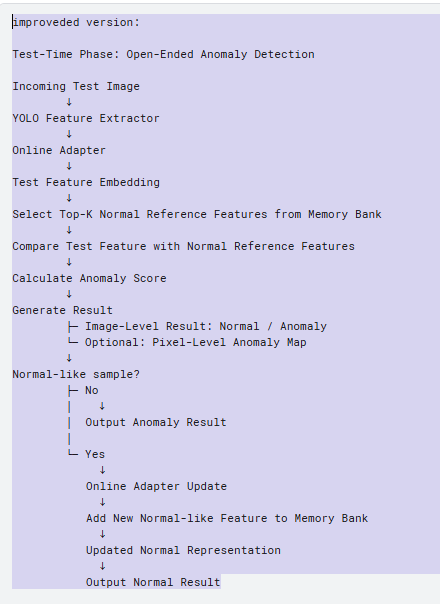

# Training Stage:
Normal samples are embedded by a frozen YOLO-based feature extractor and mapped through an adapter into a compact normal memory bank.

# Test-Time Stage:
Each incoming sample is encoded and compared against the normal memory bank to produce an anomaly score.

# Online Adaptation Stage:
When a test sample is assessed as sufficiently normal-like, it is used to update the adapter and enrich the memory bank, enabling continuous adaptation to distribution changes.

In [1]:
# ============================================================
# CELL 1 — Install packages
# Kaggle / Jupyter note:
# 1) Turn ON Internet in Notebook Settings
# 2) Turn ON GPU in Notebook Settings if you want faster feature extraction
# 3) Run this cell first. If ultralytics was installed for the first time,
#    restart the kernel/session once, then run from this cell again.
# ============================================================

import sys
import subprocess
import importlib.util

def install_if_missing(package_name, pip_name=None):
    """
    Install package into the CURRENT notebook Python environment.
    This avoids the common error:
        ModuleNotFoundError: No module named 'ultralytics'
    """
    pip_name = pip_name or package_name
    if importlib.util.find_spec(package_name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"{package_name} already installed.")

install_if_missing("ultralytics")
install_if_missing("sklearn", "scikit-learn")

# ============================================================
# CELL 2 — Imports
# ============================================================

import os
import random
import shutil
from pathlib import Path
from collections import deque

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from ultralytics import YOLO
import ultralytics

print("Ultralytics version:", ultralytics.__version__)
print("Python executable:", sys.executable)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Installing ultralytics ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.1 MB/s eta 0:00:00
sklearn already installed.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.56
Python executable: /usr/bin/python3
Device: cuda


In [2]:
# ============================================================
# CELL 3 — User config
# Change CATEGORY to another MVTec object later if needed
# ============================================================
MVTec_ROOT = Path("/kaggle/input/datasets/ipythonx/mvtec-ad")
WORK_ROOT = Path("/kaggle/working/mvtec_yolo26_ttl")
IMG_SIZE = 224        # classification-friendly size
BATCH_SIZE = 32
NUM_WORKERS = 2 if DEVICE == "cuda" else 0
RUN_ALL_CATEGORIES = True
CATEGORIES = [
    "bottle", "cable", "capsule", "carpet", "grid",
    "hazelnut", "leather", "metal_nut", "pill", "screw",
    "tile", "toothbrush", "transistor", "wood", "zipper"
]

# Online TTL settings
MAX_MEMORY_BANK = 4000         # cap bank size to control memory
VAL_NORMAL_QUANTILE = 0.995    # threshold from validation normal scores
ONLINE_LR = 1e-4
ONLINE_STEPS = 1               # number of update steps per accepted sample
CONSISTENCY_WEIGHT = 1.0
ANCHOR_WEIGHT = 0.1
ACCEPT_MARGIN = 0.95           # online update only if score < threshold * margin

# Open-ended reference comparison settings
TOP_K_REFERENCES = 5          # select Top-K most similar normal references
REFERENCE_WEIGHT = 0.7        # weight for Top-K reference score
GLOBAL_WEIGHT = 0.3           # weight for full memory-bank score

# Check dataset root exists
assert MVTec_ROOT.exists(), f"Path not found: {MVTec_ROOT}"

# Check all categories exist
missing_categories = [cat for cat in CATEGORIES if not (MVTec_ROOT / cat).exists()]

if missing_categories:
    raise FileNotFoundError(f"Missing categories: {missing_categories}")
else:
    print("All categories found successfully.")

print("Input root:", MVTec_ROOT)
print("Work root:", WORK_ROOT)
print("Run all categories:", RUN_ALL_CATEGORIES)
print("Total categories:", len(CATEGORIES))

All categories found successfully.
Input root: /kaggle/input/datasets/ipythonx/mvtec-ad
Work root: /kaggle/working/mvtec_yolo26_ttl
Run all categories: True
Total categories: 15


In [3]:
# ============================================================
# CELL 4 — Convert MVTec category into a clean working layout
#
# Why do this?
# - MVTec images may be PNG and organized by defect folders
# - We convert everything to RGB JPG for a consistent pipeline
# - We create:
#     train/normal
#     val/normal
#     test/normal
#     test/anomaly
#
# Important:
# - This preserves the anomaly-detection protocol:
#   training uses only "good" images
# - Defect images stay in test/anomaly
# ============================================================

def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def save_as_jpg(src_path: Path, dst_path: Path, size=(224, 224)):
    img = Image.open(src_path).convert("RGB")
    img = img.resize(size)
    img.save(dst_path, quality=95)


def prepare_mvtec_single_category(
    mvtec_root: Path,
    category: str,
    out_root: Path,
    img_size: int = 224,
    val_ratio: float = 0.2,
):
    category_root = mvtec_root / category
    train_good = sorted((category_root / "train" / "good").glob("*"))
    test_root = category_root / "test"

    # Output structure
    train_normal_dir = out_root / category / "train" / "normal"
    val_normal_dir   = out_root / category / "val" / "normal"
    test_normal_dir  = out_root / category / "test" / "normal"
    test_anom_dir    = out_root / category / "test" / "anomaly"

    for d in [train_normal_dir, val_normal_dir, test_normal_dir, test_anom_dir]:
        reset_dir(d)

    # Split normal train into train/val
    indices = list(range(len(train_good)))
    random.shuffle(indices)
    split_idx = int(len(indices) * (1 - val_ratio))
    train_idx = set(indices[:split_idx])

    # Convert train/val normal images
    for i, src in enumerate(train_good):
        stem = src.stem
        if i in train_idx:
            dst = train_normal_dir / f"{stem}.jpg"
        else:
            dst = val_normal_dir / f"{stem}.jpg"
        save_as_jpg(src, dst, size=(img_size, img_size))

    # Convert test images
    for defect_folder in sorted(test_root.iterdir()):
        if not defect_folder.is_dir():
            continue

        defect_name = defect_folder.name

        for src in sorted(defect_folder.glob("*")):
            stem = f"{defect_name}_{src.stem}.jpg"

            if defect_name == "good":
                dst = test_normal_dir / stem
            else:
                dst = test_anom_dir / stem

            save_as_jpg(src, dst, size=(img_size, img_size))

    return {
        "train_normal": train_normal_dir,
        "val_normal": val_normal_dir,
        "test_normal": test_normal_dir,
        "test_anomaly": test_anom_dir,
    }


print("Cell 4 ready: dataset preparation function defined.")
print("Dataset conversion will be executed inside Cell 10 for each category.")

Cell 4 ready: dataset preparation function defined.
Dataset conversion will be executed inside Cell 10 for each category.


In [4]:
# ============================================================
# CELL 5 — Quick visual check
# ============================================================

def show_samples(folder: Path, n=6, title="Samples"):
    files = sorted(folder.glob("*.jpg"))[:n]

    if len(files) == 0:
        print(f"No images found in: {folder}")
        return

    plt.figure(figsize=(14, 4))

    for i, f in enumerate(files, 1):
        img = Image.open(f).convert("RGB")
        plt.subplot(1, n, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f.name[:20], fontsize=8)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


print("Cell 5 ready: show_samples() function defined.")
print("Run visual checking after Cell 10 using one selected category.")

Cell 5 ready: show_samples() function defined.
Run visual checking after Cell 10 using one selected category.


In [5]:
# ============================================================
# CELL 6 — Dataset classes
# We keep labels simple:
#   0 = normal
#   1 = anomaly
# ============================================================
class MVTecBinaryDataset(Dataset):
    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = labels

    def __len__(self):
        return len(self.image_paths)

    def _load_image(self, path):
        img = Image.open(path).convert("RGB")
        img = np.array(img).astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))  # HWC -> CHW
        return torch.tensor(img, dtype=torch.float32)

    def __getitem__(self, idx):
        x = self._load_image(self.image_paths[idx])
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y, str(self.image_paths[idx])


def get_loader_from_folder(folder: Path, label: int, batch_size=32, shuffle=False):
    image_paths = sorted(folder.glob("*.jpg"))
    labels = [label] * len(image_paths)

    ds = MVTecBinaryDataset(image_paths, labels)

    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
    )

    return ds, dl


print("Cell 6 ready: dataset class and dataloader function defined.")
print("Dataloaders will be created inside Cell 10 for each category.")

Cell 6 ready: dataset class and dataloader function defined.
Dataloaders will be created inside Cell 10 for each category.


In [6]:
# ============================================================
# CELL 7 — YOLO26 feature extractor
#
# We use the latest Ultralytics classification backbone:
#   yolo26n-cls.pt
#
# Strategy:
# - Load YOLO26 classification model
# - Freeze the full backbone
# - Capture the input to the final Linear layer as the embedding
#
# This is a practical way to use YOLO as a feature extractor for anomaly scoring.
# ============================================================
class YOLO26FeatureExtractor(nn.Module):
    def __init__(self, model_name="yolo26n-cls.pt"):
        super().__init__()

        # Load Ultralytics classification model
        self.yolo = YOLO(model_name)
        self.core = self.yolo.model.to(DEVICE).eval()

        # Freeze all pretrained weights
        for p in self.core.parameters():
            p.requires_grad = False

        # Find the last Linear layer and hook its input as embedding
        self._cached_feat = None
        self.last_linear = None
        for m in self.core.modules():
            if isinstance(m, nn.Linear):
                self.last_linear = m

        if self.last_linear is None:
            raise RuntimeError("Could not find a final Linear layer for embedding extraction.")

        def pre_hook(module, inputs):
            # inputs is a tuple; the first item is the feature tensor entering the classifier
            self._cached_feat = inputs[0]

        self.hook = self.last_linear.register_forward_pre_hook(pre_hook)

    @torch.no_grad()
    def extract(self, x):
        """
        x: float tensor in [0, 1], shape [B, 3, H, W]
        returns: L2-normalized embedding [B, D]
        """
        self._cached_feat = None
        _ = self.core(x)  # forward pass populates the hook

        if self._cached_feat is None:
            raise RuntimeError("Feature hook did not capture embeddings.")

        feat = self._cached_feat
        if feat.ndim > 2:
            feat = torch.flatten(feat, start_dim=1)

        feat = F.normalize(feat, dim=1)
        return feat

feature_extractor = YOLO26FeatureExtractor(model_name="yolo26n-cls.pt")
print("YOLO26 feature extractor ready.")

YOLO26 feature extractor ready.


In [7]:
# ============================================================
# CELL 8 — Learnable online adapter
#
# This is the actual "test-time learning" part.
# We do not update the frozen YOLO backbone.
# We only update a lightweight adapter online.
#
# The adapter starts as identity.
# ============================================================

class OnlineAdapter(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()
        self.proj = nn.Linear(feat_dim, feat_dim, bias=False)

        # Initialize as identity
        with torch.no_grad():
            self.proj.weight.copy_(torch.eye(feat_dim))

    def forward(self, x):
        x = self.proj(x)
        x = F.normalize(x, dim=1)
        return x


print("Cell 8 ready: OnlineAdapter class defined.")
print("Adapter and optimizer will be created inside Cell 10 for each category.")

Cell 8 ready: OnlineAdapter class defined.
Adapter and optimizer will be created inside Cell 10 for each category.


In [8]:
# ============================================================
# CELL 9 — Utility functions for Open-Ended Online TTL
# ============================================================
@torch.no_grad()
def build_memory_bank(loader, extractor, adapter_model):
    """
    Build memory bank from normal training images only.
    This memory bank represents the normal feature distribution.
    """
    bank = []
    extractor.core.eval()
    adapter_model.eval()

    for x, _, _ in loader:
        x = x.to(DEVICE)

        # Extract YOLO feature
        feat = extractor.extract(x)

        # Pass through adapter
        feat = adapter_model(feat)

        # Store normal feature
        bank.append(feat.detach().cpu())

    bank = torch.cat(bank, dim=0)
    return bank


@torch.no_grad()
def select_topk_references(embedding, memory_bank, top_k=5):
    """
    Select Top-K most similar normal reference features from memory bank.

    embedding: [B, D]
    memory_bank: [N, D]

    returns:
        topk_refs: [B, K, D]
        topk_sim:  [B, K]
    """
    bank = memory_bank.to(embedding.device)

    # Cosine similarity because features are L2-normalized
    sim = embedding @ bank.T   # [B, N]

    k = min(top_k, bank.shape[0])
    topk_sim, topk_idx = torch.topk(sim, k=k, dim=1)

    topk_refs = bank[topk_idx]  # [B, K, D]
    return topk_refs, topk_sim


@torch.no_grad()
def open_ended_anomaly_score(
    embedding,
    memory_bank,
    top_k=5,
    reference_weight=0.7,
    global_weight=0.3
):
    """
    Open-ended anomaly scoring.

    Difference from old version:
    - Old version compares test feature with the whole memory bank directly.
    - New version first selects Top-K normal references, then compares.

    Higher score = more anomalous.
    """
    bank = memory_bank.to(embedding.device)

    # 1. Global memory-bank similarity
    global_sim = embedding @ bank.T
    global_max_sim, _ = global_sim.max(dim=1)
    global_score = 1.0 - global_max_sim

    # 2. Top-K reference similarity
    _, topk_sim = select_topk_references(
        embedding=embedding,
        memory_bank=memory_bank,
        top_k=top_k
    )

    # Use average Top-K similarity as reference similarity
    ref_sim = topk_sim.mean(dim=1)
    ref_score = 1.0 - ref_sim

    # 3. Combined score
    score = reference_weight * ref_score + global_weight * global_score

    return score


@torch.no_grad()
def open_ended_anomaly_score_single(
    embedding,
    memory_bank,
    top_k=5,
    reference_weight=0.7,
    global_weight=0.3
):
    """
    Single image scoring version.
    Used during online test-time loop where batch_size = 1.
    """
    score = open_ended_anomaly_score(
        embedding=embedding,
        memory_bank=memory_bank,
        top_k=top_k,
        reference_weight=reference_weight,
        global_weight=global_weight
    )
    return score[0].item()


@torch.no_grad()
def nearest_normal_anchor(embedding, memory_bank, top_k=5):
    """
    Use Top-K normal references as anchor.
    Instead of only using the nearest one, use the average of Top-K references.
    This is more stable for open-ended detection.
    """
    topk_refs, _ = select_topk_references(
        embedding=embedding,
        memory_bank=memory_bank,
        top_k=top_k
    )

    # Average Top-K reference features
    anchor = topk_refs.mean(dim=1)
    anchor = F.normalize(anchor, dim=1)

    return anchor


def weak_aug(x):
    """
    Mild augmentation for consistency learning.
    """
    noise = torch.randn_like(x) * 0.01
    out = torch.clamp(x + noise, 0.0, 1.0)
    return out


def strong_aug(x):
    """
    Stronger augmentation for online test-time learning.
    """
    noise = torch.randn_like(x) * 0.03
    out = torch.clamp(x + noise, 0.0, 1.0)

    # Random horizontal flip
    if random.random() < 0.5:
        out = torch.flip(out, dims=[3])

    return out


def online_ttl_update_open_ended(
    x,
    extractor,
    adapter_model,
    optimizer,
    memory_bank,
    top_k=5
):
    """
    Online Test-Time Learning update.

    Important:
    - YOLO feature extractor is frozen.
    - Only adapter is updated.
    - Update is only called when sample is normal-like.
    """
    adapter_model.train()

    for _ in range(ONLINE_STEPS):
        xw = weak_aug(x)
        xs = strong_aug(x)

        with torch.no_grad():
            fw = extractor.extract(xw)
            fs = extractor.extract(xs)

        zw = adapter_model(fw)
        zs = adapter_model(fs)

        # Top-K reference anchor from memory bank
        with torch.no_grad():
            anchor = nearest_normal_anchor(
                embedding=zw.detach(),
                memory_bank=memory_bank,
                top_k=top_k
            ).to(DEVICE)

        # Consistency loss: same image under different augmentation should be close
        consistency_loss = F.mse_loss(zs, zw.detach())

        # Anchor loss: keep normal-like sample close to normal references
        anchor_loss = F.mse_loss(zw, anchor)

        loss = CONSISTENCY_WEIGHT * consistency_loss + ANCHOR_WEIGHT * anchor_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    adapter_model.eval()


@torch.no_grad()
def compute_scores(loader, extractor, adapter_model, memory_bank):
    """
    Compute scores for validation/test set using open-ended reference comparison.
    """
    scores, labels, paths = [], [], []
    adapter_model.eval()

    for x, y, p in loader:
        x = x.to(DEVICE)

        feat = extractor.extract(x)
        emb = adapter_model(feat)

        batch_scores = open_ended_anomaly_score(
            embedding=emb,
            memory_bank=memory_bank,
            top_k=TOP_K_REFERENCES,
            reference_weight=REFERENCE_WEIGHT,
            global_weight=GLOBAL_WEIGHT
        )

        scores.extend(batch_scores.cpu().tolist())
        labels.extend(y.cpu().tolist())
        paths.extend(list(p))

    return scores, labels, paths

In [9]:
# ============================================================
# CELL 10 — Build Memory Bank for All 15 Categories
# ============================================================

all_category_data = {}

for CATEGORY in CATEGORIES:
    print("=" * 70)
    print(f"Preparing category: {CATEGORY}")
    print("=" * 70)

    # Prepare dataset folder
    paths = prepare_mvtec_single_category(
        mvtec_root=MVTec_ROOT,
        category=CATEGORY,
        out_root=WORK_ROOT,
        img_size=IMG_SIZE,
        val_ratio=0.2,
    )

    # Train normal loader
    train_ds, train_loader = get_loader_from_folder(
        paths["train_normal"],
        label=0,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    # Validation normal loader
    val_ds, val_loader = get_loader_from_folder(
        paths["val_normal"],
        label=0,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # Test loader: normal + anomaly
    test_normal_paths = sorted(paths["test_normal"].glob("*.jpg"))
    test_anomaly_paths = sorted(paths["test_anomaly"].glob("*.jpg"))

    test_image_paths = test_normal_paths + test_anomaly_paths
    test_labels = [0] * len(test_normal_paths) + [1] * len(test_anomaly_paths)

    test_ds = MVTecBinaryDataset(test_image_paths, test_labels)

    test_loader = DataLoader(
        test_ds,
        batch_size=1,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
    )

    # Reset adapter for each category
    x0, _, _ = next(iter(train_loader))
    x0 = x0.to(DEVICE)

    with torch.no_grad():
        f0 = feature_extractor.extract(x0)

    FEAT_DIM = f0.shape[1]

    adapter = OnlineAdapter(FEAT_DIM).to(DEVICE)
    adapter_optimizer = torch.optim.Adam(adapter.parameters(), lr=ONLINE_LR)

    adapter_initial_state = {
        k: v.detach().cpu().clone()
        for k, v in adapter.state_dict().items()
    }
    
    # Build memory bank from normal training images
    memory_bank = build_memory_bank(train_loader, feature_extractor, adapter)

    # Store everything for next cells
    all_category_data[CATEGORY] = {
        "paths": paths,
        "train_ds": train_ds,
        "val_ds": val_ds,
        "test_ds": test_ds,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "adapter": adapter,
        "adapter_optimizer": adapter_optimizer,
        "adapter_initial_state": adapter_initial_state,        
        "memory_bank": memory_bank
    }

    print(f"{CATEGORY} memory bank shape: {memory_bank.shape}")

print("All category memory banks prepared.")

Preparing category: bottle
bottle memory bank shape: torch.Size([167, 1280])
Preparing category: cable
cable memory bank shape: torch.Size([179, 1280])
Preparing category: capsule
capsule memory bank shape: torch.Size([175, 1280])
Preparing category: carpet
carpet memory bank shape: torch.Size([224, 1280])
Preparing category: grid
grid memory bank shape: torch.Size([211, 1280])
Preparing category: hazelnut
hazelnut memory bank shape: torch.Size([312, 1280])
Preparing category: leather
leather memory bank shape: torch.Size([196, 1280])
Preparing category: metal_nut
metal_nut memory bank shape: torch.Size([176, 1280])
Preparing category: pill
pill memory bank shape: torch.Size([213, 1280])
Preparing category: screw
screw memory bank shape: torch.Size([256, 1280])
Preparing category: tile
tile memory bank shape: torch.Size([184, 1280])
Preparing category: toothbrush
toothbrush memory bank shape: torch.Size([48, 1280])
Preparing category: transistor
transistor memory bank shape: torch.Size

In [10]:
# ============================================================
# CELL 11 — Threshold Calibration for All 15 Categories
#
# Estimate the anomaly threshold from the upper tail of scores on
# held-out normal images. This avoids using defect labels for threshold tuning.
# ============================================================

for CATEGORY in CATEGORIES:
    print("=" * 70)
    print(f"Calculating threshold for: {CATEGORY}")
    print("=" * 70)

    data = all_category_data[CATEGORY]

    val_scores, _, _ = compute_scores(
        data["val_loader"],
        feature_extractor,
        data["adapter"],
        data["memory_bank"]
    )

    threshold = float(np.quantile(val_scores, VAL_NORMAL_QUANTILE))

    data["threshold"] = threshold
    data["val_scores"] = val_scores

    print(f"{CATEGORY} threshold: {threshold:.6f}")
    print(f"Val score min : {np.min(val_scores):.6f}")
    print(f"Val score mean: {np.mean(val_scores):.6f}")
    print(f"Val score max : {np.max(val_scores):.6f}")

print("All thresholds calculated.")

Calculating threshold for: bottle
bottle threshold: 0.010987
Val score min : 0.002404
Val score mean: 0.004792
Val score max : 0.011011
Calculating threshold for: cable
cable threshold: 0.045996
Val score min : 0.026281
Val score mean: 0.034674
Val score max : 0.046132
Calculating threshold for: capsule
capsule threshold: 0.009949
Val score min : 0.003944
Val score mean: 0.006709
Val score max : 0.009973
Calculating threshold for: carpet
carpet threshold: 0.008934
Val score min : 0.002272
Val score mean: 0.003649
Val score max : 0.009734
Calculating threshold for: grid
grid threshold: 0.029805
Val score min : 0.006447
Val score mean: 0.015622
Val score max : 0.030232
Calculating threshold for: hazelnut
hazelnut threshold: 0.069465
Val score min : 0.024970
Val score mean: 0.038235
Val score max : 0.070740
Calculating threshold for: leather
leather threshold: 0.007451
Val score min : 0.002785
Val score mean: 0.004504
Val score max : 0.007461
Calculating threshold for: metal_nut
metal_nut

In [11]:
# ============================================================
# CELL 12 — Online Test-Time Learning + Evaluation for All Categories
#
# Full test-time flow:
# 1. Loop through all 15 MVTec AD categories
# 2. For each test image, extract feature using frozen YOLO
# 3. Pass feature through online adapter
# 4. Compare test feature with Top-K normal references from memory bank
# 5. Calculate anomaly score
# 6. If sample is normal-like, update adapter and memory bank
# 7. If sample is anomalous, reject it from update
# 8. Calculate final prediction and evaluation metrics
# ============================================================

all_results = []

for CATEGORY in CATEGORIES:
    print("=" * 70)
    print(f"Running online test-time evaluation for: {CATEGORY}")
    print("=" * 70)

    # --------------------------------------------------------
    # Load prepared data from Cell 10 and Cell 11
    # --------------------------------------------------------
    data = all_category_data[CATEGORY]

    adapter = data["adapter"]
    adapter_optimizer = data["adapter_optimizer"]
    memory_bank = data["memory_bank"]
    threshold = data["threshold"]
    test_loader = data["test_loader"]

    # Clone memory bank because this version will be updated online
    memory_bank_online = memory_bank.clone()

    # Set adapter to evaluation mode before testing
    adapter.eval()

    # Store results for this category
    test_scores_before = []
    test_scores_after = []
    test_preds_after = []
    test_gt = []
    test_paths = []

    # --------------------------------------------------------
    # Test images are processed one by one
    # This simulates online / streaming test-time learning
    # --------------------------------------------------------
    for x, y, p in test_loader:
        x = x.to(DEVICE)
        gt = int(y.item())

        # ----------------------------------------------------
        # Step 1: Extract feature before online adaptation
        # ----------------------------------------------------
        with torch.no_grad():
            # Frozen YOLO feature extractor
            feat_before = feature_extractor.extract(x)

            # Online adapter maps YOLO feature into adapted feature space
            emb_before = adapter(feat_before)

            # Open-ended anomaly scoring:
            # compare with Top-K normal reference features
            score_before = open_ended_anomaly_score_single(
                embedding=emb_before,
                memory_bank=memory_bank_online,
                top_k=TOP_K_REFERENCES,
                reference_weight=REFERENCE_WEIGHT,
                global_weight=GLOBAL_WEIGHT
            )

        # ----------------------------------------------------
        # Step 2: Decide whether this sample is normal-like
        #
        # If score is lower than threshold, it looks normal.
        # Only normal-like samples are used for online update.
        # This prevents anomaly contamination in the memory bank.
        # ----------------------------------------------------
        is_normal_like = score_before < threshold * ACCEPT_MARGIN

        # ----------------------------------------------------
        # Step 3: Online Test-Time Learning update
        # Only update if sample is normal-like
        # ----------------------------------------------------
        if is_normal_like:
            online_ttl_update_open_ended(
                x=x,
                extractor=feature_extractor,
                adapter_model=adapter,
                optimizer=adapter_optimizer,
                memory_bank=memory_bank_online,
                top_k=TOP_K_REFERENCES
            )

            # ------------------------------------------------
            # Step 4: Extract updated feature after adapter update
            # ------------------------------------------------
            with torch.no_grad():
                feat_updated = feature_extractor.extract(x)
                emb_updated = adapter(feat_updated)

            # ------------------------------------------------
            # Step 5: Add accepted normal-like feature to memory bank
            # ------------------------------------------------
            memory_bank_online = torch.cat(
                [memory_bank_online, emb_updated.detach().cpu()],
                dim=0
            )

            # Limit memory size to avoid unlimited growth
            if memory_bank_online.shape[0] > MAX_MEMORY_BANK:
                memory_bank_online = memory_bank_online[-MAX_MEMORY_BANK:]

        # ----------------------------------------------------
        # Step 6: Final scoring after possible online update
        # ----------------------------------------------------
        with torch.no_grad():
            feat_after = feature_extractor.extract(x)
            emb_after = adapter(feat_after)

            score_after = open_ended_anomaly_score_single(
                embedding=emb_after,
                memory_bank=memory_bank_online,
                top_k=TOP_K_REFERENCES,
                reference_weight=REFERENCE_WEIGHT,
                global_weight=GLOBAL_WEIGHT
            )

        # ----------------------------------------------------
        # Step 7: Final prediction
        #
        # score >= threshold → anomaly
        # score < threshold  → normal
        # ----------------------------------------------------
        pred_after = 1 if score_after >= threshold else 0

        # Save result
        test_scores_before.append(score_before)
        test_scores_after.append(score_after)
        test_preds_after.append(pred_after)
        test_gt.append(gt)
        test_paths.append(p[0])

    # --------------------------------------------------------
    # Step 8: Evaluation metrics for this category
    # --------------------------------------------------------
    auroc_before = roc_auc_score(test_gt, test_scores_before)
    auroc_after = roc_auc_score(test_gt, test_scores_after)

    cm = confusion_matrix(test_gt, test_preds_after)

    report = classification_report(
        test_gt,
        test_preds_after,
        target_names=["normal", "anomaly"],
        digits=4,
        output_dict=True
    )
    
    print(f"\n{CATEGORY} completed.")
    
    # --------------------------------------------------------
    # Store detailed results back into dictionary
    # This allows Cell 13 and Cell 15 to reuse the data
    # --------------------------------------------------------
    data["test_scores_before"] = test_scores_before
    data["test_scores_after"] = test_scores_after
    data["test_preds_after"] = test_preds_after
    data["test_gt"] = test_gt
    data["test_paths"] = test_paths
    data["memory_bank_online"] = memory_bank_online
    data["confusion_matrix"] = cm
    data["classification_report"] = report

    # --------------------------------------------------------
    # Store summary result for overall table
    # --------------------------------------------------------
    all_results.append({
        "category": CATEGORY,
        "train_normal": len(data["train_ds"]),
        "val_normal": len(data["val_ds"]),
        "test_total": len(data["test_ds"]),
        "threshold": threshold,
        "auroc_before": auroc_before,
        "auroc_after": auroc_after,
        "normal_precision": report["normal"]["precision"],
        "normal_recall": report["normal"]["recall"],
        "anomaly_precision": report["anomaly"]["precision"],
        "anomaly_recall": report["anomaly"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "memory_bank_initial": memory_bank.shape[0],
        "memory_bank_final": memory_bank_online.shape[0],
    })

print("All online test-time evaluations completed.")

Running online test-time evaluation for: bottle

bottle completed.
Running online test-time evaluation for: cable

cable completed.
Running online test-time evaluation for: capsule

capsule completed.
Running online test-time evaluation for: carpet

carpet completed.
Running online test-time evaluation for: grid

grid completed.
Running online test-time evaluation for: hazelnut

hazelnut completed.
Running online test-time evaluation for: leather

leather completed.
Running online test-time evaluation for: metal_nut

metal_nut completed.
Running online test-time evaluation for: pill

pill completed.
Running online test-time evaluation for: screw

screw completed.
Running online test-time evaluation for: tile

tile completed.
Running online test-time evaluation for: toothbrush

toothbrush completed.
Running online test-time evaluation for: transistor

transistor completed.
Running online test-time evaluation for: wood

wood completed.
Running online test-time evaluation for: zipper

zip

In [12]:
# ============================================================
# CELL 13 — Overall Results Summary + Confusion Matrix + Report
# ============================================================

import pandas as pd

# Convert all category results into table
results_df = pd.DataFrame(all_results)

# Show summary table
display(results_df)

# ------------------------------------------------------------
# Overall AUROC comparison (Shows how well the model separates  
# normal and anomaly samples overall.)
# ------------------------------------------------------------
print("=" * 70)
print("Overall AUROC Summary")
print("=" * 70)

print("Average AUROC before TTL:", results_df["auroc_before"].mean())
print("Average AUROC after TTL :", results_df["auroc_after"].mean())

# ------------------------------------------------------------
# Best and weakest category
# ------------------------------------------------------------
print("\nBest categories after TTL:")
display(results_df.sort_values("auroc_after", ascending=False).head())

print("\nWeakest categories after TTL:")
display(results_df.sort_values("auroc_after", ascending=True).head())

# --------------------------------------------------------------------------------------------
# Confusion matrix (Shows actual prediction mistakes based on selected threshold)
# and Classification report (Shows precision, recall, and F1-score for normal and anomaly classes)
# per category 
# --------------------------------------------------------------------------------------------
for CATEGORY in CATEGORIES:
    print("=" * 70)
    print(f"Detailed Evaluation Report: {CATEGORY}")
    print("=" * 70)

    data = all_category_data[CATEGORY]

    print("Confusion Matrix:")
    print(data["confusion_matrix"])

    print("\nClassification Report:")
    print(classification_report(
        data["test_gt"],
        data["test_preds_after"],
        target_names=["normal", "anomaly"],
        digits=4
    ))
    

,category,train_normal,val_normal,test_total,threshold,auroc_before,auroc_after,normal_precision,normal_recall,anomaly_precision,anomaly_recall,macro_f1,memory_bank_initial,memory_bank_final
0,bottle,167,42,83,0.010987,0.969048,0.966667,0.888889,0.800000,0.938462,0.968254,0.897615,167,183
1,cable,179,45,150,0.045996,0.385495,0.375000,0.381944,0.948276,0.500000,0.032609,0.302889,179,323
2,capsule,175,44,132,0.009949,0.725967,0.724372,0.625000,0.217391,0.854839,0.972477,0.616226,175,182
3,carpet,224,56,117,0.008934,0.699438,0.693018,0.291667,0.500000,0.797101,0.617978,0.532312,224,269
4,grid,211,53,78,0.029805,0.797828,0.801170,0.451613,0.666667,0.851064,0.701754,0.653846,211,239
5,hazelnut,312,79,110,0.069465,0.381071,0.360714,0.386139,0.975000,0.888889,0.114286,0.377862,312,410
6,leather,196,49,124,0.007451,0.827785,0.828465,0.800000,0.125000,0.764706,0.989130,0.539388,196,201
7,metal_nut,176,44,115,0.052900,0.211632,0.172532,0.200000,1.000000,1.000000,0.053763,0.217687,176,286
8,pill,213,54,167,0.028235,0.111020,0.103110,0.090909,0.500000,0.458333,0.078014,0.143590,213,355
9,screw,256,64,160,0.031663,0.857553,0.856118,0.518519,0.341463,0.796992,0.890756,0.626517,256,282


Overall AUROC Summary
Average AUROC before TTL: 0.6384934525241679
Average AUROC after TTL : 0.6306603807080295

Best categories after TTL:


,category,train_normal,val_normal,test_total,threshold,auroc_before,auroc_after,normal_precision,normal_recall,anomaly_precision,anomaly_recall,macro_f1,memory_bank_initial,memory_bank_final
0,bottle,167,42,83,0.010987,0.969048,0.966667,0.888889,0.800000,0.938462,0.968254,0.897615,167,183
13,wood,197,50,79,0.030125,0.962281,0.961404,0.866667,0.684211,0.906250,0.966667,0.850095,197,211
10,tile,184,46,117,0.015860,0.952381,0.949495,0.894737,0.515152,0.836735,0.976190,0.777473,184,200
11,toothbrush,48,12,42,0.023759,0.855556,0.858333,0.625000,0.416667,0.794118,0.900000,0.671875,48,55
9,screw,256,64,160,0.031663,0.857553,0.856118,0.518519,0.341463,0.796992,0.890756,0.626517,256,282



Weakest categories after TTL:


,category,train_normal,val_normal,test_total,threshold,auroc_before,auroc_after,normal_precision,normal_recall,anomaly_precision,anomaly_recall,macro_f1,memory_bank_initial,memory_bank_final
8,pill,213,54,167,0.028235,0.111020,0.103110,0.090909,0.500000,0.458333,0.078014,0.143590,213,355
7,metal_nut,176,44,115,0.052900,0.211632,0.172532,0.200000,1.000000,1.000000,0.053763,0.217687,176,286
14,zipper,192,48,151,0.016995,0.366597,0.347426,0.170213,0.500000,0.719298,0.344538,0.359939,192,283
5,hazelnut,312,79,110,0.069465,0.381071,0.360714,0.386139,0.975000,0.888889,0.114286,0.377862,312,410
1,cable,179,45,150,0.045996,0.385495,0.375000,0.381944,0.948276,0.500000,0.032609,0.302889,179,323


Detailed Evaluation Report: bottle
Confusion Matrix:
[[16  4]
 [ 2 61]]

Classification Report:
              precision    recall  f1-score   support

      normal     0.8889    0.8000    0.8421        20
     anomaly     0.9385    0.9683    0.9531        63

    accuracy                         0.9277        83
   macro avg     0.9137    0.8841    0.8976        83
weighted avg     0.9265    0.9277    0.9264        83

Detailed Evaluation Report: cable
Confusion Matrix:
[[55  3]
 [89  3]]

Classification Report:
              precision    recall  f1-score   support

      normal     0.3819    0.9483    0.5446        58
     anomaly     0.5000    0.0326    0.0612        92

    accuracy                         0.3867       150
   macro avg     0.4410    0.4904    0.3029       150
weighted avg     0.4544    0.3867    0.2481       150

Detailed Evaluation Report: capsule
Confusion Matrix:
[[  5  18]
 [  3 106]]

Classification Report:
              precision    recall  f1-score   support


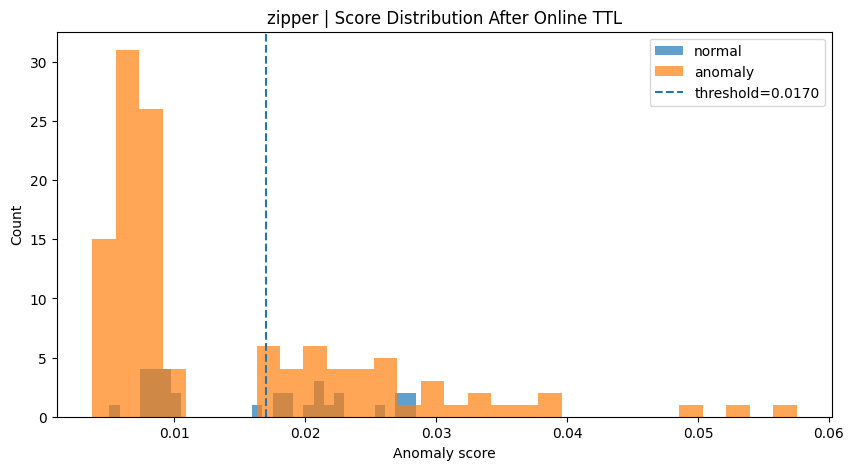

In [13]:
# ============================================================
# CELL 14 — Plot score distributions
# ============================================================
normal_scores = [s for s, y in zip(test_scores_after, test_gt) if y == 0]
anomaly_scores = [s for s, y in zip(test_scores_after, test_gt) if y == 1]

plt.figure(figsize=(10, 5))
plt.hist(normal_scores, bins=30, alpha=0.7, label="normal")
plt.hist(anomaly_scores, bins=30, alpha=0.7, label="anomaly")
plt.axvline(threshold, linestyle="--", label=f"threshold={threshold:.4f}")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.title(f"{CATEGORY} | Score Distribution After Online TTL")
plt.legend()
plt.show()

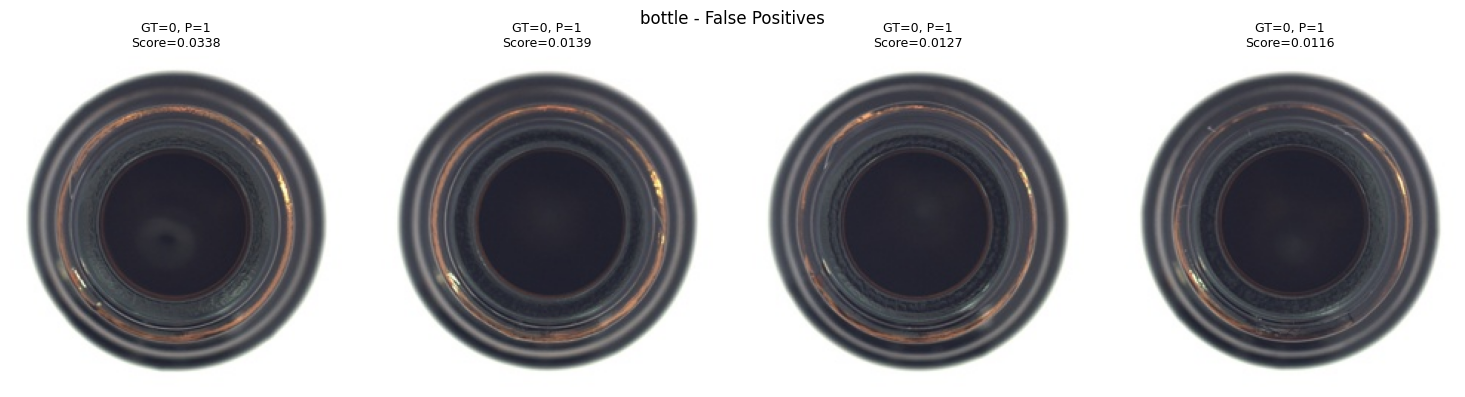

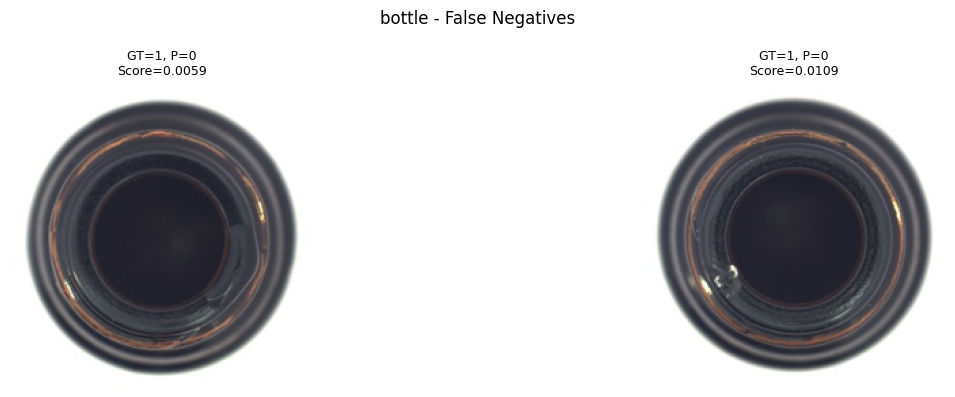

In [14]:
# ============================================================
# CELL 15 — Visual Error Analysis for One Selected Category
# ============================================================

SELECTED_CATEGORY = "bottle"

data = all_category_data[SELECTED_CATEGORY]

results = list(zip(
    data["test_paths"],
    data["test_gt"],
    data["test_scores_after"],
    data["test_preds_after"]
))

# False positives: normal predicted as anomaly
fps = [r for r in results if r[1] == 0 and r[3] == 1]
fps = sorted(fps, key=lambda x: x[2], reverse=True)[:6]

# False negatives: anomaly predicted as normal
fns = [r for r in results if r[1] == 1 and r[3] == 0]
fns = sorted(fns, key=lambda x: x[2])[:6]

def show_error_cases(cases, title):
    if len(cases) == 0:
        print(f"No cases for: {title}")
        return

    plt.figure(figsize=(15, 4))

    for i, (path, gt, score, pred) in enumerate(cases, 1):
        img = Image.open(path).convert("RGB")

        plt.subplot(1, len(cases), i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"GT={gt}, P={pred}\nScore={score:.4f}", fontsize=9)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_error_cases(fps, f"{SELECTED_CATEGORY} - False Positives")
show_error_cases(fns, f"{SELECTED_CATEGORY} - False Negatives")

In [15]:
# ============================================================
# CELL 16 — Save outputs for selected deployment category
# ============================================================

import json
import numpy as np
import torch

SELECTED_CATEGORY = "bottle"   # change here when needed

data = all_category_data[SELECTED_CATEGORY]

OUT_DIR = WORK_ROOT / SELECTED_CATEGORY / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

adapter = data["adapter"]
memory_bank = data["memory_bank"]
threshold = data["threshold"]

np.save(OUT_DIR / "test_scores_before.npy", np.array(data["test_scores_before"]))
np.save(OUT_DIR / "test_scores_after.npy", np.array(data["test_scores_after"]))
np.save(OUT_DIR / "test_gt.npy", np.array(data["test_gt"]))
np.save(OUT_DIR / "test_preds_after.npy", np.array(data["test_preds_after"]))
np.save(OUT_DIR / "test_paths.npy", np.array([str(p) for p in data["test_paths"]]))

torch.save(memory_bank, OUT_DIR / "memory_bank.pt")

torch.save({
    "adapter_state_dict": data["adapter_initial_state"],
    "category": SELECTED_CATEGORY,
    "threshold": float(threshold),
    "img_size": int(IMG_SIZE),
    "top_k_references": int(TOP_K_REFERENCES),
    "reference_weight": float(REFERENCE_WEIGHT),
    "global_weight": float(GLOBAL_WEIGHT),
    "accept_margin": float(ACCEPT_MARGIN),
    "export_state": "initial_adapter_initial_memory_bank"
}, OUT_DIR / "ttl_adapter.pt")

with open(OUT_DIR / "threshold.json", "w") as f:
    json.dump({
        "category": SELECTED_CATEGORY,
        "threshold": float(threshold),
        "img_size": int(IMG_SIZE),
        "top_k_references": int(TOP_K_REFERENCES),
        "reference_weight": float(REFERENCE_WEIGHT),
        "global_weight": float(GLOBAL_WEIGHT),
        "accept_margin": float(ACCEPT_MARGIN),
        "val_normal_quantile": float(VAL_NORMAL_QUANTILE),
        "max_memory_bank": int(MAX_MEMORY_BANK),
        "online_lr": float(ONLINE_LR)
    }, f, indent=4)

print("Saved deployment category:", SELECTED_CATEGORY)
print("Saved to:", OUT_DIR)
print("Threshold:", threshold)

Saved deployment category: bottle
Saved to: /kaggle/working/mvtec_yolo26_ttl/bottle/outputs
Threshold: 0.010986708430573344
